E0000 00:00:1751063202.697823 2128816 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751063202.701183 2128816 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751063202.710026 2128816 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751063202.710035 2128816 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751063202.710036 2128816 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751063202.710037 2128816 computation_placer.cc:177] computation placer already registered. Please check linka

Using 1 GPU(s) for acceleration
Creating training dataset...
Found 16 TFRecord files


I0000 00:00:1751063204.787470 2128816 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9123 MB memory:  -> device: 0, name: NVIDIA RTX A2000 12GB, pci bus id: 0000:01:00.0, compute capability: 8.6


Creating validation dataset...
Found 4 TFRecord files

==== TRAINING SET STATISTICS ====

Calculating class statistics...


2835it [00:14, 189.66it/s]



================ CLASS DISTRIBUTION REPORT ================
Total Patches: 90,706
Total Pixels:  5,944,508,416

Class           Pixel Count     Pixel %         Patches Containing   % of Patches        
-------------------------------------------------------------------------------------
BACKGROUND      3,948,665,691   66.4254        % 80,090               88.30               %
CLOUD           1,795,058,076   30.1969        % 51,812               57.12               %
SHADOW          200,784,649     3.3776         % 21,937               24.18               %

==== VALIDATION SET STATISTICS ====

Calculating class statistics...


705it [00:05, 119.41it/s]



================ CLASS DISTRIBUTION REPORT ================
Total Patches: 22,547
Total Pixels:  1,477,640,192

Class           Pixel Count     Pixel %         Patches Containing   % of Patches        
-------------------------------------------------------------------------------------
BACKGROUND      1,223,510,069   82.8016        % 22,266               98.75               %
CLOUD           175,527,963     11.8789        % 8,453                37.49               %
SHADOW          78,602,160      5.3194         % 7,752                34.38               %

Saved sample visualization to patch_samples.png

Debugging complete!


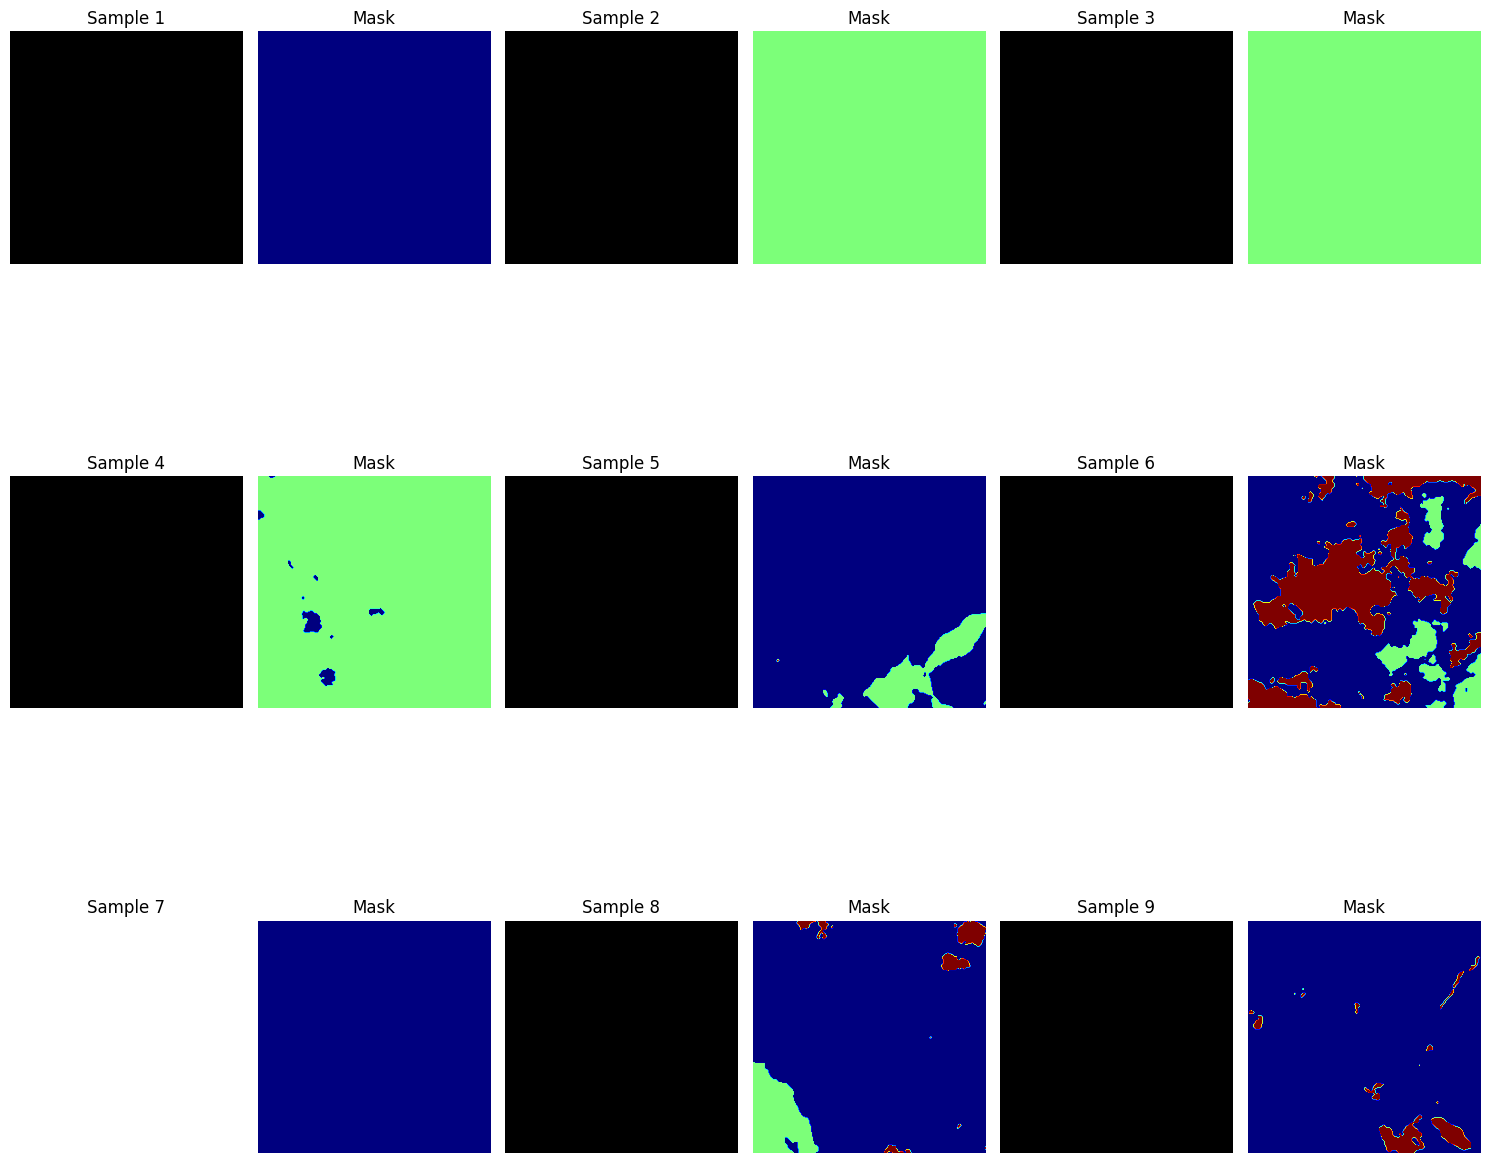

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Reduce TensorFlow logging
import tensorflow as tf
import numpy as np
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

# ======================= CONFIGURATION =======================
PATCH_SIZE = 256
BATCH_SIZE = 32  # Larger batch for efficient counting
CLASS_NAMES = ['BACKGROUND', 'CLOUD', 'SHADOW']
PATCH_DIR = "/home/btech1/isro/dataset/patches"  # Update with your path

# ======================= DATA PARSING =======================
def parse_tfrecord(example):
    features = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'mask': tf.io.FixedLenFeature([], tf.string),
        'height': tf.io.FixedLenFeature([], tf.int64),
        'width': tf.io.FixedLenFeature([], tf.int64)
    }
    example = tf.io.parse_single_example(example, features)
    
    height = tf.cast(example['height'], tf.int32)
    width = tf.cast(example['width'], tf.int32)
    
    # Decode image and mask
    image = tf.io.decode_raw(example['image'], tf.float32)
    image = tf.reshape(image, (height, width, 3))
    
    mask = tf.io.decode_raw(example['mask'], tf.uint8)
    mask = tf.reshape(mask, (height, width))
    
    return image, mask

def create_debug_dataset(tfrecord_dir, batch_size=BATCH_SIZE):
    """Create dataset for debugging"""
    tfrecords = glob.glob(os.path.join(tfrecord_dir, '*.tfrecord'))
    print(f"Found {len(tfrecords)} TFRecord files")
    
    dataset = tf.data.TFRecordDataset(tfrecords, num_parallel_reads=tf.data.AUTOTUNE)
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# ======================= STATISTICS FUNCTIONS =======================
def calculate_class_statistics(dataset):
    """Calculate detailed class statistics"""
    print("\nCalculating class statistics...")
    class_counts = np.zeros(3, dtype=np.int64)
    class_patch_presence = np.zeros(3, dtype=np.int64)
    total_patches = 0
    total_pixels = 0
    
    for images, masks in tqdm(dataset):
        masks_np = masks.numpy()
        batch_size = masks_np.shape[0]
        
        # Update counts
        for class_id in range(3):
            class_mask = (masks_np == class_id)
            class_counts[class_id] += np.sum(class_mask)
            
            # Count patches containing this class
            class_patch_presence[class_id] += np.any(class_mask.reshape(batch_size, -1), axis=1).sum()
        
        total_patches += batch_size
        total_pixels += np.prod(masks_np.shape)
    
    # Calculate percentages
    class_percentages = class_counts / total_pixels * 100
    patch_presence_percentages = class_patch_presence / total_patches * 100
    
    return {
        'class_counts': class_counts,
        'class_percentages': class_percentages,
        'patch_presence': class_patch_presence,
        'patch_presence_percentages': patch_presence_percentages,
        'total_patches': total_patches,
        'total_pixels': total_pixels
    }

def print_statistics(stats):
    """Print formatted statistics"""
    print("\n================ CLASS DISTRIBUTION REPORT ================")
    print(f"Total Patches: {stats['total_patches']:,}")
    print(f"Total Pixels:  {stats['total_pixels']:,}\n")
    
    print("{:<15} {:<15} {:<15} {:<20} {:<20}".format(
        'Class', 'Pixel Count', 'Pixel %', 'Patches Containing', '% of Patches'))
    print("-" * 85)
    
    for i, name in enumerate(CLASS_NAMES):
        print("{:<15} {:<15,} {:<15.4f}% {:<20,} {:<20.2f}%".format(
            name,
            stats['class_counts'][i],
            stats['class_percentages'][i],
            stats['patch_presence'][i],
            stats['patch_presence_percentages'][i]
        ))

# ======================= VISUALIZATION FUNCTIONS =======================
def visualize_sample_patches(dataset, num_samples=9):
    """Visualize random sample patches"""
    print("\nCollecting sample patches...")
    
    # Collect all patches first
    all_images = []
    all_masks = []
    
    for images, masks in dataset.unbatch().take(1000):  # Consider first 1000 patches
        all_images.append(images)
        all_masks.append(masks)
    
    # Select random samples
    indices = random.sample(range(len(all_images)), min(num_samples, len(all_images)))
    sample_images = [all_images[i] for i in indices]
    sample_masks = [all_masks[i] for i in indices]
    
    # Create plot
    plt.figure(figsize=(15, 15))
    for i in range(len(sample_images)):
        plt.subplot(3, 6, 2*i+1)
        plt.imshow(sample_images[i].numpy())
        plt.title(f"Sample {i+1}")
        plt.axis('off')
        
        plt.subplot(3, 6, 2*i+2)
        plt.imshow(sample_masks[i].numpy(), vmin=0, vmax=2, cmap='jet')
        plt.title("Mask")
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig("patch_samples.png")
    print("Saved sample visualization to patch_samples.png")

# ======================= MAIN DEBUG FUNCTION =======================
def debug_class_distribution():
    # Create datasets
    train_dir = os.path.join(PATCH_DIR, "train")
    val_dir = os.path.join(PATCH_DIR, "val")
    
    print("Creating training dataset...")
    train_ds = create_debug_dataset(train_dir)
    
    print("Creating validation dataset...")
    val_ds = create_debug_dataset(val_dir)
    
    # Calculate and print statistics
    print("\n==== TRAINING SET STATISTICS ====")
    train_stats = calculate_class_statistics(train_ds)
    print_statistics(train_stats)
    
    print("\n==== VALIDATION SET STATISTICS ====")
    val_stats = calculate_class_statistics(val_ds)
    print_statistics(val_stats)
    
    # Visualize samples
    visualize_sample_patches(train_ds)

if __name__ == "__main__":
    # Configure GPU if available
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print(f"Using {len(gpus)} GPU(s) for acceleration")
        except RuntimeError as e:
            print(e)
    
    debug_class_distribution()
    print("\nDebugging complete!")

In [5]:
import os
import numpy as np
import rasterio
from rasterio.errors import NotGeoreferencedWarning
import warnings

# Suppress warnings about missing georeferencing
warnings.simplefilter("ignore", NotGeoreferencedWarning)

def replace_nan_with_zero_in_tiffs(folder_path):
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(".tif"):
            file_path = os.path.join(folder_path, filename)
            print(f"Processing: {file_path}")
            
            with rasterio.open(file_path, 'r+') as src:
                for i in range(1, src.count + 1):
                    band = src.read(i)
                    
                    # Check for NaN and replace with 0
                    if np.isnan(band).any():
                        band_cleaned = np.nan_to_num(band, nan=0)
                        src.write(band_cleaned, i)
                    else:
                        print(f"  No NaNs in band {i}")

if __name__ == "__main__":
    folder = "/home/btech1/isro/dataset/left"  # Replace with your folder path
    replace_nan_with_zero_in_tiffs(folder)


Processing: /home/btech1/isro/dataset/left/RAF25JAN2025042220009700055SSANSTUC00GTDB.tif
Processing: /home/btech1/isro/dataset/left/RAF23MAR2025043024009400045SSANSTUC00GTDC.tif
